# The solow-model for a small open economy   

Imports and set magics:

**Write out the model in equations here.** 

Make sure you explain well the purpose of the model and comment so that other students who may not have seen it before can follow.  

# OPEN ECONOMY SOLOW MODEL - Capital mobility

## Analytical solution

1. $K_t$ is capital
2. $L_t$ is labor (growing with a constant rate of $n$)
3. $A_t$ is technology (growing with a constant rate of $g$)
4. $Y_t = F(K_t,A_tL_t)$ is GDP
5. $Y=C+I+NX\Leftrightarrow Y+rF=C+NX+rF$ Is the national accounts identity, where $F$ is holdings of foreign capital and $r$ is the real rate of return

6. $NX_{t}+rF=F_{t+1}-F_{t}$
7. $S_{t}=Y_{t}+rF-C_{t}\Leftrightarrow S_{t}=I_{t}+F_{t+1}-F_{t}$ Hence savings can be used to accumulate foreing assets or domestic capital
8. $K_{t+1}=I_{t}+K_{t}\Leftrightarrow K_{t+1}=S_{t}+K_{t}+F_{t}$
9. $V_{t}=K_{t}+F_{t}$ is Wealth


Production is assumed to follow a Cobb-douglas production fucntion:
$$Y_{t}=AK_{t}^{\alpha}L_{t}^{1-\alpha}$$

People save a fraction of the total income: In the open economy

$S_{t}=s(Y_{t}+rF_{t}) $


Capital accumulates as :
$$K_{t+1}^{i}+\bar{K}_{t+1}^{i}=S_{t}+(1-\delta)+K_{t}^{i}+(1-\delta)\bar{K}_{t}^{i}\Leftrightarrow$$
 
$$V_{t+1}=S_{t}+(1-\delta)V_{t} $$

Real rate is :
$$\bar{r}=r_{t}$$
$$r_{t}=B\alpha K_{t}^{\alpha-1}L_{t}^{1-\alpha}$$


## Pr. worker values 

$$k^*=(\frac{B\alpha}{\bar{r}})^{\frac{1}{1-\alpha}}$$
$$y^*=B^{\frac{1}{1-\alpha}}\frac{\alpha}{\bar{r}}^{\frac{\alpha}{1-\alpha}}$$
$$w^*=(1-\alpha)B^{\frac{1}{1-\alpha}} (\frac{\alpha}{\bar{r}})^{\frac{\alpha}{1-\alpha}}$$

## Transition equation

For Wealth:
$$v_{t+1}=\frac{sw^*}{1+n}+\frac{1-\delta+s\bar{r}}{1+n}v_t$$



**Normalizing** $$v_t$$ gives the equation of:
$$v=\frac{sw^*}{1+n}+\frac{1-\delta+s\bar{r}}{1+n}v$$


## Numerical solution

**Firtsly we solve the model, and find the steady state value for wealth**

In [33]:
import numpy as np
import scipy as sp
import sympy as sm

v = sm.symbols('v')
wSS = sm.symbols('w*')
delta = sm.symbols('delta')
s = sm.symbols('s')
r = sm.symbols('r')
n = sm.symbols('n')

In [34]:
ss = sm.Eq(v,((s*wSS/(1+n)+((1-delta+s*r)/(1+n))*v)))
vss = sm.solve(ss,v)[0]
vss

s*w*/(delta + n - r*s)

**We calculate the realwage**

In [35]:
alphaa = 0.3
B = 1
r1 = 0.02

wstar = (1-alphaa)*B**(1/(1-alphaa))*(alphaa/r1)**(alphaa/(1-alphaa))

wstar


2.2342777006521617

**Then we define the solution, as a function**
The calibration values are taken from macro 1 winter exam 2024.

In [36]:
ss_func = sm.lambdify((s,n,r,delta,wSS),vss)

# Evaluate function
ss_func(0.2,0.02,0.02,0.05,2.23)

6.757575757575758

We proceed to solve the steady state using numerical root-finding with optimize.scalar

In [37]:
import scipy.optimize as optimize

s = 0.2
r = 0.02
n = 0.02
delta = 0.05
wss = 2.23

obj_vss = lambda v: v - (((s * wss / (1 + n) + ((1 - delta + s * r) / (1 + n)) * v)))
result = optimize.root_scalar(obj_vss, bracket=[0.1, 100], method='brentq')

print('The steady state for v is', result.root)

The steady state for v is 6.7575757575757445


**We note that the solutions are identical we have therefore found the steady state values**

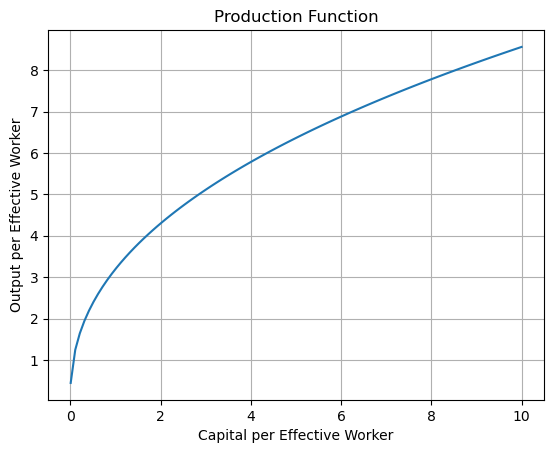

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
s = 0.2
r = 0.02
n = 0.02
delta = 0.05
wss = 2.23
A = 1  # Let's assume TFP (A) is 1 for simplicity - as in the book of H.J Whitta and P.B. Sørensen

# Steady state capital per effective worker
vss = 6.75 

# Production function
def production_function(v, A, alpha, r):
    return A**(1/(1-alpha)) * (v * alpha/r)**(alpha/(1-alpha))

# Define range for capital per effective worker (v)
v_values = np.linspace(0.01, 10, 100)  # Adjust the range as needed

# Calculate output for each value of capital per effective worker
output_values = production_function(v_values, A, 0.3, r)  # Assuming alpha is 0.3

# Plotting
plt.plot(v_values, output_values)
plt.title('Production Function')
plt.xlabel('Capital per Effective Worker')
plt.ylabel('Output per Effective Worker')
plt.grid(True)
plt.show()


We note that the open solow model explores diminishing return to scale. 

## Wealth accumulation in the open economy:

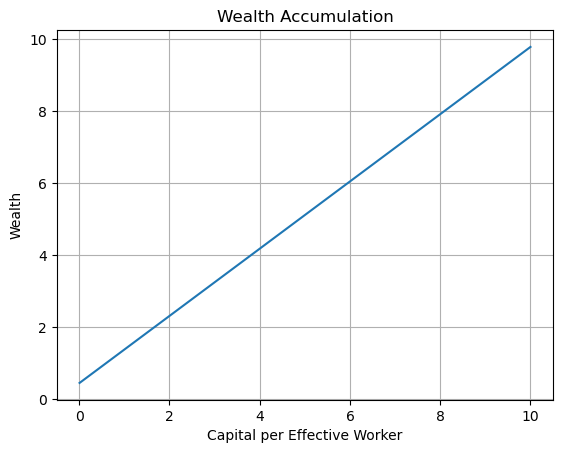

In [39]:
wealth_accumulation = (s * wstar / (1 + n)) + ((1 - delta + s * r) / (1 + n)) * v
import matplotlib.pyplot as plt

# Parameters
s = 0.2
r = 0.02
n = 0.02
delta = 0.05
wstar = 2.23

# Function for wealth accumulation
def wealth_accumulation(v, s, n, r, delta, wstar):
    return (s * wstar / (1 + n)) + ((1 - delta + s * r) / (1 + n)) * v

# Define range for capital per effective worker (v)
v_values = np.linspace(0.01, 10, 100)  # Adjust the range as needed

# Calculate wealth accumulation for each value of capital per effective worker
wealth_values = wealth_accumulation(v_values, s, n, r, delta, wstar)

# Plotting
plt.plot(v_values, wealth_values)
plt.title('Wealth Accumulation')
plt.xlabel('Capital per Effective Worker')
plt.ylabel('Wealth')
plt.grid(True)
plt.show()


# Further analysis

Make detailed vizualizations of how your model changes with parameter values. 

Try to make an extension of the model. 

In this part we will evaluate different shocks to the model

The following code down below will show different scenarios of the savings rate, $s$. Hereby we can see this parameters impact on the wealth in the economy.

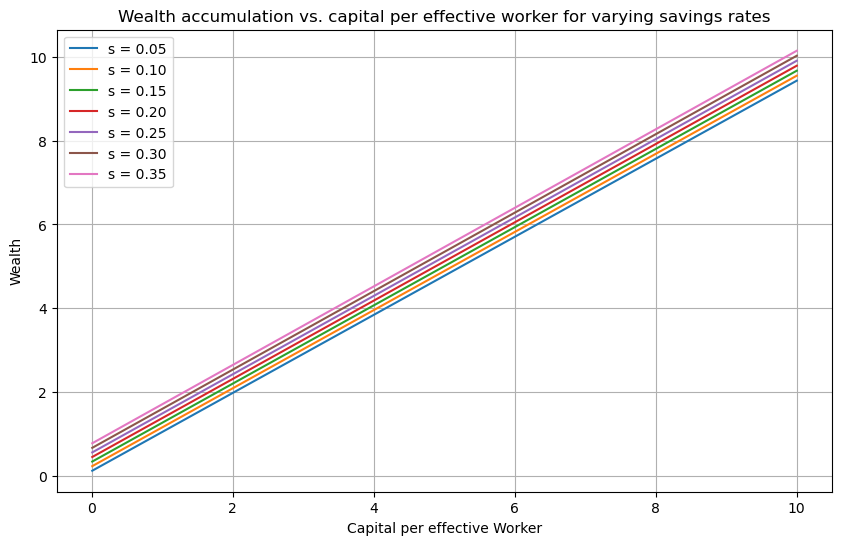

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Model parameters
n = 0.02
r = 0.02
delta = 0.05
wstar = 2.23  # Steady state wage

# Function for wealth accumulation
def wealth_accumulation(v, s, n, r, delta, wstar):
    return (s * wstar / (1 + n)) + ((1 - delta + s * r) / (1 + n)) * v

# Define range for capital per effective worker (v)
v_values = np.linspace(0.01, 10, 100)

# Different savings rates for comparison
s_values = np.linspace(0.05, 0.35, 7)  # From 5% to 35% savings rate

plt.figure(figsize=(10, 6))
for s in s_values:
    wealth_values = wealth_accumulation(v_values, s, n, r, delta, wstar)
    plt.plot(v_values, wealth_values, label=f's = {s:.2f}')

plt.title('Wealth accumulation vs. capital per effective worker for varying savings rates')
plt.xlabel('Capital per effective Worker')
plt.ylabel('Wealth')
plt.legend()
plt.grid(True)
plt.show()

The following code will do the same, but for the depreciation rate, $\delta$. We go from a depreciation rate of 1 to 10 procent.

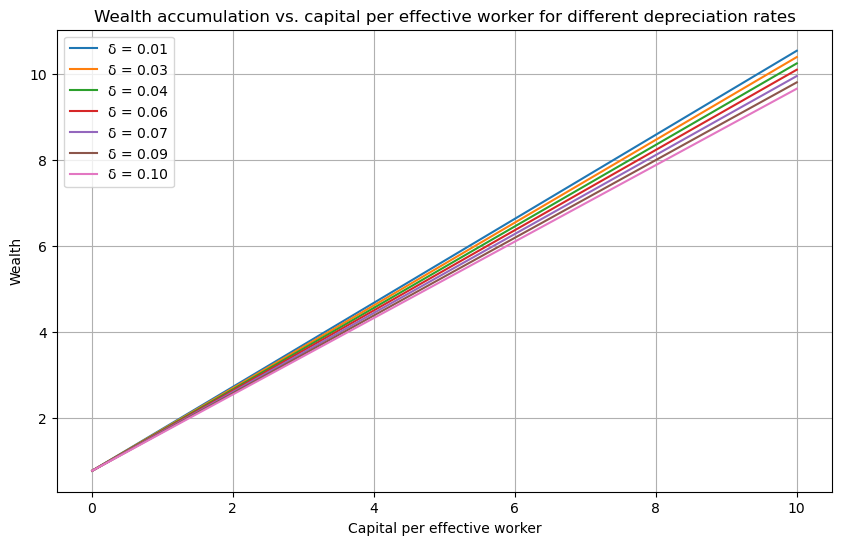

In [41]:
delta_values = np.linspace(0.01, 0.1, 7)  # From 1% to 10% depreciation rate

plt.figure(figsize=(10, 6))
for delta in delta_values:
    wealth_values = wealth_accumulation(v_values, s, n, r, delta, wstar)
    plt.plot(v_values, wealth_values, label=f'δ = {delta:.2f}')

plt.title('Wealth accumulation vs. capital per effective worker for different depreciation rates')
plt.xlabel('Capital per effective worker')
plt.ylabel('Wealth')
plt.legend()
plt.grid(True)
plt.show()


The following code shows a positive shock to the productivity in the economy

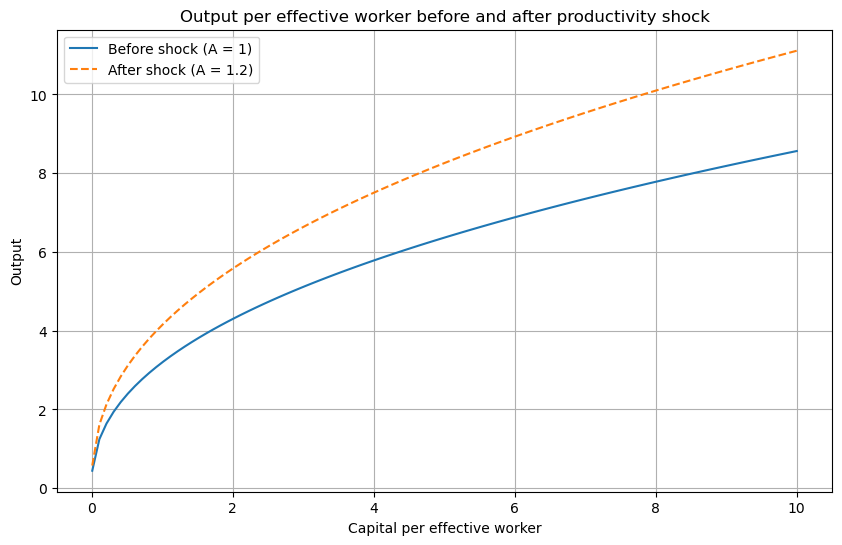

In [42]:
# Adjusted production function to include productivity
def production_function(v, A, alpha, r):
    return A**(1/(1-alpha)) * (v * alpha/r)**(alpha/(1-alpha))

# Parameters before and after the productivity shock
A_before = 1  # Productivity before the shock
A_after = 1.2  # Productivity after the shock (shock scenario)

# Calculate output for each value of capital per effective worker before and after the shock
output_values_before = production_function(v_values, A_before, 0.3, r)
output_values_after = production_function(v_values, A_after, 0.3, r)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(v_values, output_values_before, label=f'Before shock (A = {A_before})')
plt.plot(v_values, output_values_after, label=f'After shock (A = {A_after})', linestyle='--')

plt.title('Output per effective worker before and after productivity shock')
plt.xlabel('Capital per effective worker')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.show()


# Conclusion

We conclude that the numerical steady state value for wealth is 6,75. We see that y_t* has diminishin return of scale, and that a positive schock to technolegy, will give a higher output pr. person. We also investigate the effects of different savingsrate and depriceations rates.